In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle

#PATH = pathlib.Path(__file__).parent.resolve()
DET_I = 5 #SBND ?
DET_A = 4*np.pi*1e4# Find detector area

flavours = {
     14: (r"$\nu_\mu$",     "blue"),
    -14: (r"$\bar\nu_\mu$", "orange"),
     12: (r"$\nu_e$",       "green"),
    -12: (r"$\bar\nu_e$",   "red"),
}


In [2]:
with uproot.open("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root") as f:
    
    print(f.keys())
    tree = f[f.keys()[0]]
    meta = f[f.keys()[2]]

    nuray_E   = tree["nuray"]["nuray.E"].array()
    nuray_wgt = tree["nuray"]["nuray.wgt"].array()
    nimpwt    = tree["decay"]["decay.nimpwt"].array()
    ntype     = tree["decay"]["decay.ntype"].array()
    ptype     = tree["decay"]["decay.ptype"].array() 
    pots = meta["pots"].array()
    
    for entry in tree:
        print(entry.name)
        for entry2 in entry:
            print("\t",entry2.name)
            for entry3 in entry2:
                print("\t\t",entry3.name)
    

    print(meta["location"]["location.x"].array())
    print(meta["location"]["location.y"].array())
    print(meta["location"]["location.z"].array())

['dk2nuTree;2', 'dk2nuTree;1', 'dkmetaTree;1']
dk2nu
	 job
	 potnum
	 decay
		 decay.norig
		 decay.ndecay
		 decay.ntype
		 decay.vx
		 decay.vy
		 decay.vz
		 decay.pdpx
		 decay.pdpy
		 decay.pdpz
		 decay.ppdxdz
		 decay.ppdydz
		 decay.pppz
		 decay.ppenergy
		 decay.ppmedium
		 decay.ptype
		 decay.muparpx
		 decay.muparpy
		 decay.muparpz
		 decay.mupare
		 decay.necm
		 decay.nimpwt
	 nuray
		 nuray.px
		 nuray.py
		 nuray.pz
		 nuray.E
		 nuray.wgt
	 ancestor
		 ancestor.pdg
		 ancestor.startx
		 ancestor.starty
		 ancestor.startz
		 ancestor.startt
		 ancestor.startpx
		 ancestor.startpy
		 ancestor.startpz
		 ancestor.stoppx
		 ancestor.stoppy
		 ancestor.stoppz
		 ancestor.polx
		 ancestor.poly
		 ancestor.polz
		 ancestor.pprodpx
		 ancestor.pprodpy
		 ancestor.pprodpz
		 ancestor.nucleus
		 ancestor.parIndex
		 ancestor.proc
		 ancestor.ivol
		 ancestor.imat
	 ppvx
	 ppvy
	 ppvz
	 tgtexit
		 tgtexit.tvx
		 tgtexit.tvy
		 tgtexit.tvz
		 tgtexit.tpx
		 tgtexit.tpy
		 tgtexi

In [3]:
# Select SBND
energies = nuray_E[:,DET_I]
wgts     = nuray_wgt[:,DET_I]
tot_wgts = nimpwt * wgts / (DET_A * pots[0])

# Type and Parents
is_numu      = (ntype == 14)
is_anumu     = (ntype == -14)
is_nue       = (ntype == 12)
is_anue      = (ntype == -12)

parent_groups = {
    "mu" : (np.isin(ptype, [13,-13]), "blue"),
    "pi" : (np.isin(ptype, [211,-211]), "orange"),
    "K0L" : (np.isin(ptype, [130]), "red"),
    "Kpm" : (np.isin(ptype, [321, -321]), "green")
}

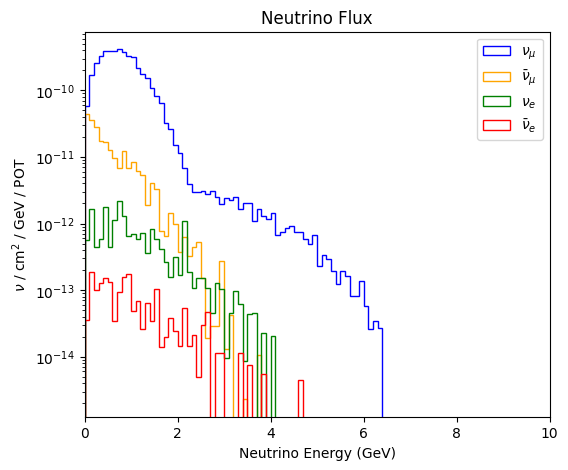

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV


for pdg, (label, colour) in flavours.items():
    mask = (ntype == pdg)
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_xlim(0,10)
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title("Neutrino Flux")
ax.legend()
ax.set_yscale("log")

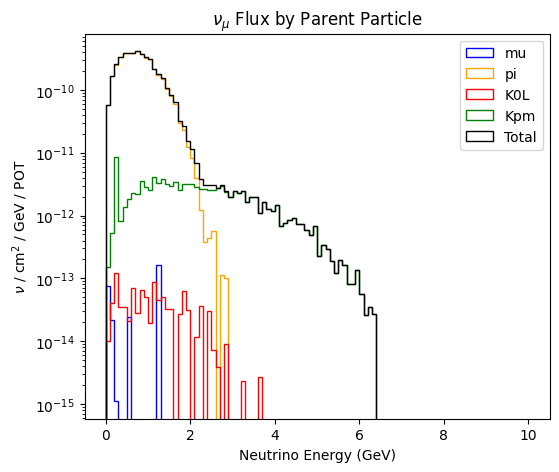

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 10, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_numu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_numu], bins=bins, weights=tot_wgts[is_numu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")
#ax.set_xlim(0,1)

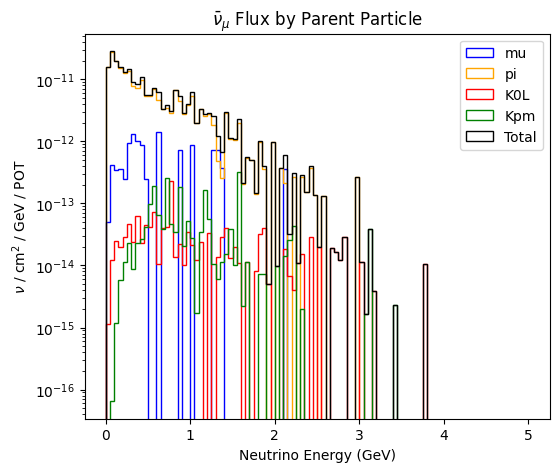

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anumu & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anumu], bins=bins, weights=tot_wgts[is_anumu], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_\mu$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

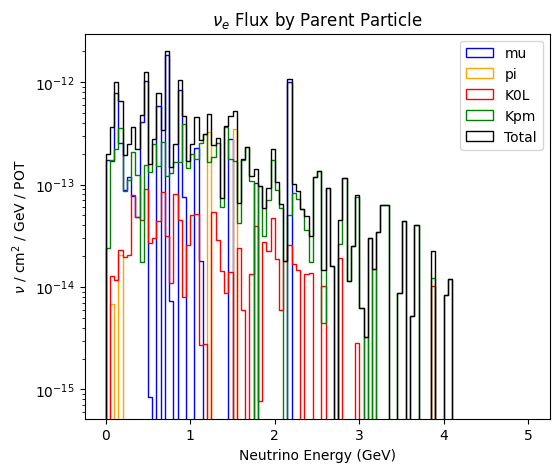

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_nue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_nue], bins=bins, weights=tot_wgts[is_nue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\nu_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

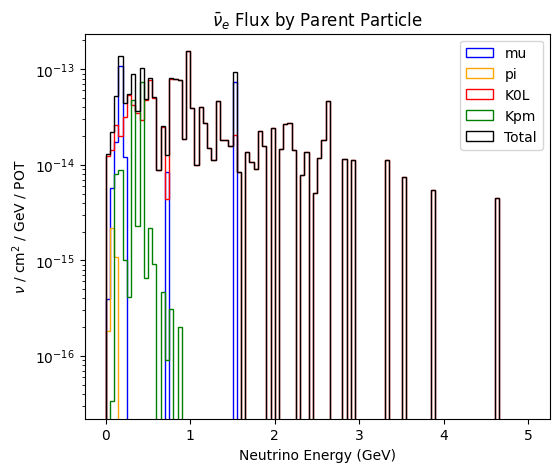

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 5, 101)  # GeV

for label, (parent_mask, colour) in parent_groups.items():
    mask = is_anue & parent_mask
    ax.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
            label=label, color=colour, histtype="step", linewidth=1)

# Total Flux
ax.hist(energies[is_anue], bins=bins, weights=tot_wgts[is_anue], label="Total", 
        color="black", histtype="step", linewidth=1)

ax.set_xlabel("Neutrino Energy (GeV)")
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_title(r"$\bar{\nu}_e$ Flux by Parent Particle")
ax.legend()
ax.set_yscale("log")

## Estimate Event Rates

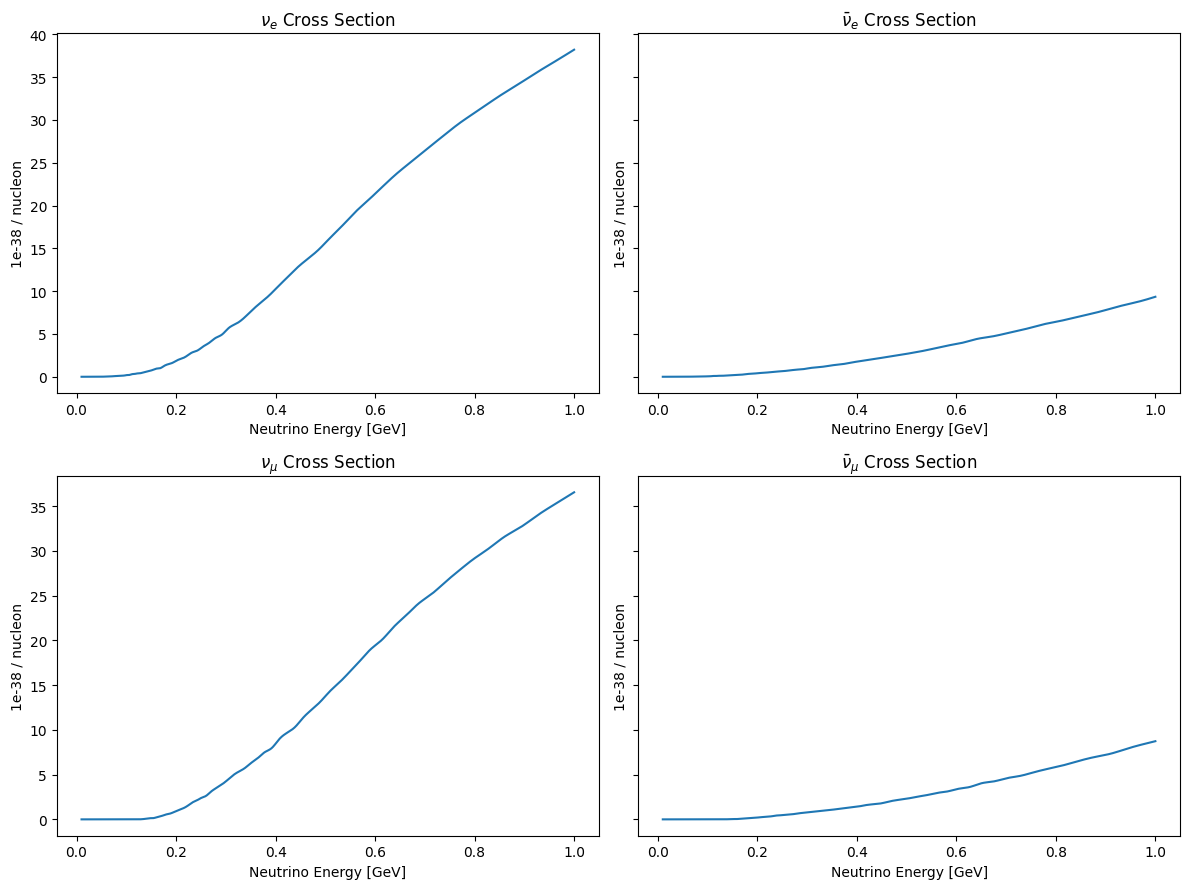

In [9]:
xsec_numu = np.loadtxt("./DATA/Genie_xs/Genie_xs/numu_Ar_v3.04.00_t.AR23.20i.00.000.txt")
xsec_anumu = np.loadtxt("./DATA/Genie_xs/Genie_xs/numu_bar_Ar_v3.04.00_t.AR23.20i.00.000.txt")
xsec_nue = np.loadtxt("./DATA/Genie_xs/Genie_xs/nue_Ar_v3.04.00_t.AR23.20i.00.000.txt")
xsec_anue = np.loadtxt("./DATA/Genie_xs/Genie_xs/nue_bar_Ar_v3.04.00_t.AR23.20i.00.000.txt")

xsec_nuc = 1e-38 / 40 # Not sure which units



fig, [row1, row2] = plt.subplots(2, 2, figsize=(12,9), sharey="row")

row1[0].plot(xsec_nue[:,0], xsec_nue[:,1])
row1[0].set_xlabel("Neutrino Energy [GeV]")
row1[0].set_ylabel("1e-38 / nucleon")
row1[0].set_title(r"$\nu_e$ Cross Section")

row1[1].plot(xsec_anue[:,0], xsec_anue[:,1])
row1[1].set_xlabel("Neutrino Energy [GeV]")
row1[1].set_ylabel("1e-38 / nucleon")
row1[1].set_title(r"$\bar{\nu}_e$ Cross Section")

row2[0].plot(xsec_numu[:,0], xsec_numu[:,1])
row2[0].set_xlabel("Neutrino Energy [GeV]")
row2[0].set_ylabel("1e-38 / nucleon")
row2[0].set_title(r"$\nu_\mu$ Cross Section")

row2[1].plot(xsec_numu[:,0], xsec_anumu[:,1])
row2[1].set_xlabel("Neutrino Energy [GeV]")
row2[1].set_ylabel("1e-38 / nucleon")
row2[1].set_title(r"$\bar{\nu}_\mu$ Cross Section")

fig.tight_layout()

In [10]:
# Same target

rho = 1.38434 #g/cm^{3}
n_a = 6.022e23 #molec/mol
m_mol = 39.95 #g/mol
A = 40
volume_cm3 = 400*400*500

n_targets = (rho * volume_cm3 * n_a * A) / (m_mol)
print('Number of target nucleons: ', n_targets)

Number of target nucleons:  6.677543313141424e+31


Estimated SBND nue_1GeV events: 2076.697277545026
Estimated SBND anue_1GeV events: 47.299799678236575
Estimated SBND numu_1GeV events: 611567.3077846963
Estimated SBND anumu_1GeV events: 3308.2988818793647


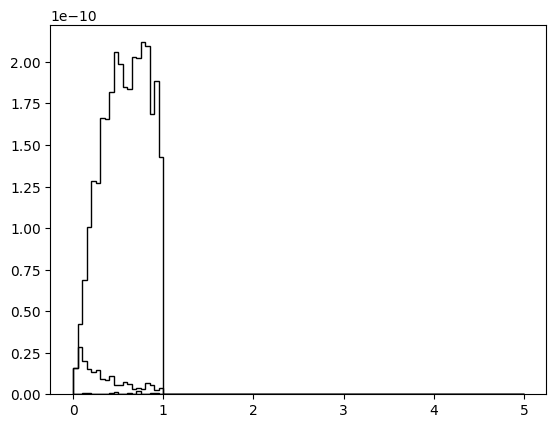

In [ ]:
events = {
    'nue_1GeV': [],
    'anue_1GeV': [],
    'numu_1GeV': [],
    'anumu_1GeV': [],
}

pot = 6.5e20

labels = events.keys()
masks =  [is_nue, is_anue, is_numu, is_anumu]
xsecs = [xsec_nue, xsec_anue, xsec_numu, xsec_anumu]


for nu_type, label, xsec in zip(masks, labels, xsecs):
    mask = nu_type & (energies <= 1)

    values, edges, _ = plt.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
                            label="Total", color="black", histtype="step", linewidth=1)

    bin_centres = (edges[1:] + edges[:-1]) / 2

    for centre, val in zip(bin_centres, values):
        xsection = np.interp(centre, xsec[:,0], xsec[:,1] * xsec_nuc)
        evt = val * pot * xsection * n_targets
        events[label].append(evt)

    print(f"Estimated SBND {label} events:", np.sum(events[label]))



Estimated SBND Kaon Decay events (235-236 MeV): 138.8847377878358


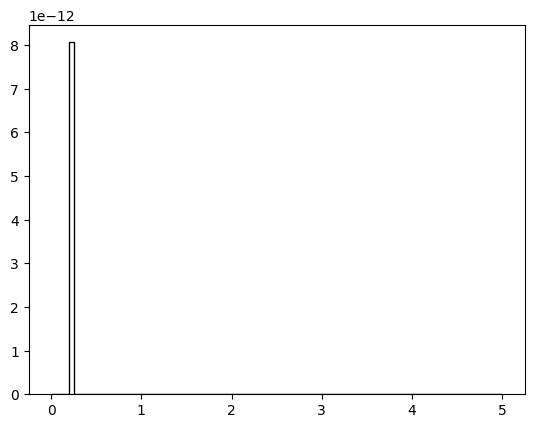

In [18]:


mask = is_numu & (parent_groups["K0L"][0] | parent_groups["Kpm"][0]) & (energies > .235) & (energies < .236)
events = []

values, edges, _ = plt.hist(energies[mask], bins=bins, weights=tot_wgts[mask],
                        label="Total", color="black", histtype="step", linewidth=1)

bin_centres = (edges[1:] + edges[:-1]) / 2

for centre, val in zip(bin_centres, values):
    xsection = np.interp(centre, xsec_numu[:,0], xsec_numu[:,1] * xsec_nuc)
    evt = val * pot * xsection * n_targets
    events.append(evt)

print(f"Estimated SBND Kaon Decay events (235-236 MeV):", np.sum(events))